In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# 1

In [2]:
def eq(x):
    return x - 0.222 * (1 - x) ** 3

x_guess = 0.5
solution = scipy.optimize.fsolve(eq, x_guess, xtol=1e-6, maxfev=1000)
x_solution = solution[0]
print(f"Solution for x: {x_solution:.4f}",)

Solution for x: 0.1408


# 2

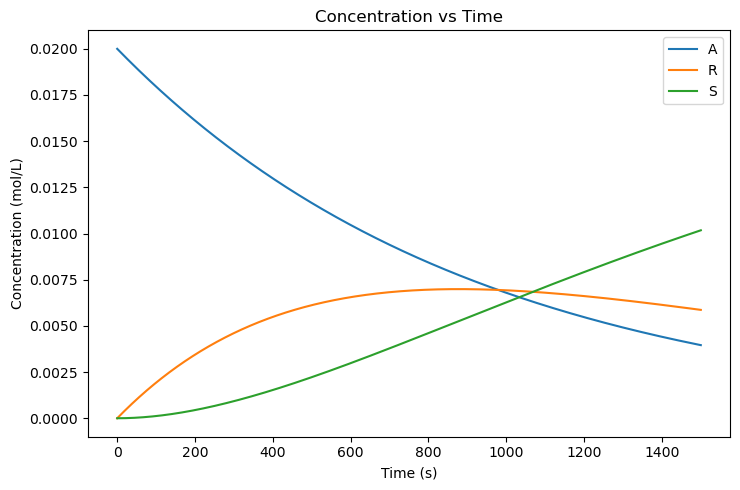

In [32]:
def ode2(t, x, k):
    a, r, s = x
    k1, k2, k3 = k  
    da_dt = -k1 * a
    dr_dt = k1 * a - k2 * r - k3 * r * s
    ds_dt = k2 * r - k3 * r * s + 2 * k3 * r * s
    return [da_dt, dr_dt, ds_dt]


x0 = [0.02, 0, 0]
k = np.array([1.08, 1.19, 1.59]) * 10**-3
    
t_span = (0, 1500)
t_eval = np.linspace(t_span[0], t_span[1], 1500)
solution = scipy.integrate.solve_ivp(ode2, t_span, x0, args=(k,), t_eval=t_eval)
a, r, s = solution.y
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(solution.t, a, label='A')
ax.plot(solution.t, r, label='R')
ax.plot(solution.t, s, label='S')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Concentration (mol/L)')
ax.set_title('Concentration vs Time')
ax.legend()
# ax.grid()
plt.tight_layout()
fig.savefig('concentration_vs_time2.pdf', dpi=300)

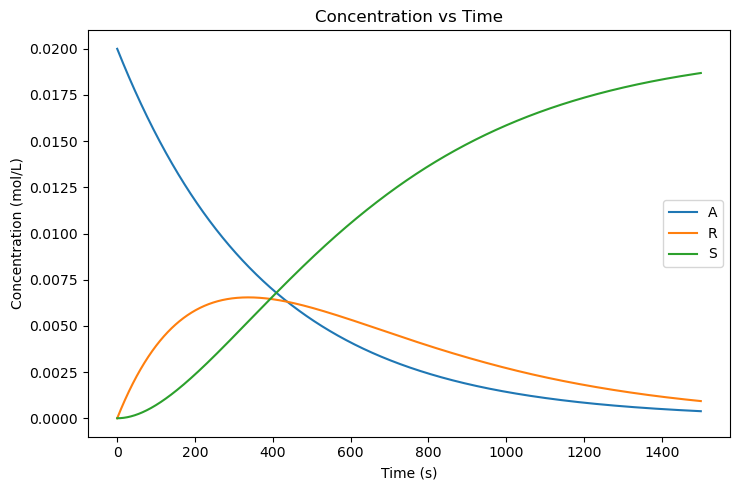

In [37]:
def ode2(t, x, k):
    a, r, s = x
    k1, k2, k3 = k
    da_dt = -k1 * a
    dr_dt = k1 * a - k2 * r - k3 * r * s
    ds_dt = k2 * r - k3 * r * s + 2 * k3 * r * s
    return [da_dt, dr_dt, ds_dt]


x0 = [0.02, 0, 0]
k = np.array([2.64, 3.3, 3.1]) * 10**-3

t_span = (0, 1500)
t_eval = np.linspace(t_span[0], t_span[1], 1500)
solution = scipy.integrate.solve_ivp(ode2, t_span, x0, args=(k,), t_eval=t_eval)
a, r, s = solution.y
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(solution.t, a, label="A")
ax.plot(solution.t, r, label="R")
ax.plot(solution.t, s, label="S")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Concentration (mol/L)")
ax.set_title("Concentration vs Time")
ax.legend()
# ax.grid()
plt.tight_layout()
fig.savefig("concentration_vs_time233.pdf", dpi=300)

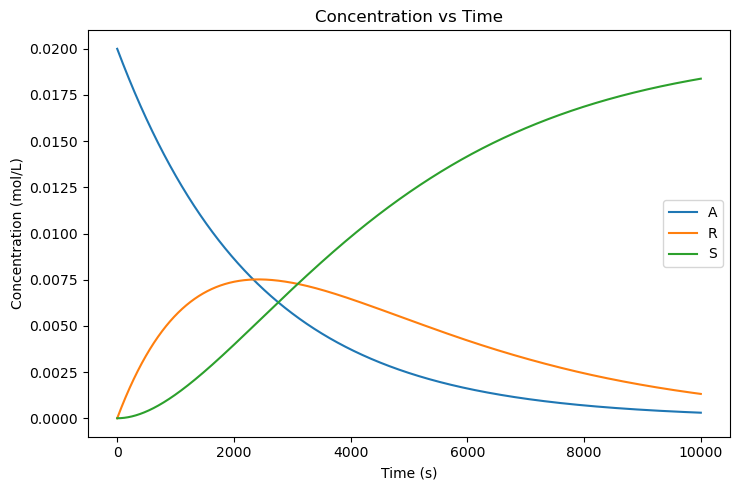

In [36]:
def ode2(t, x, k):
    a, r, s = x
    k1, k2, k3 = k
    da_dt = -k1 * a
    dr_dt = k1 * a - k2 * r - k3 * r * s
    ds_dt = k2 * r - k3 * r * s + 2 * k3 * r * s
    return [da_dt, dr_dt, ds_dt]


x0 = [0.02, 0, 0]
k = np.array([0.42, 0.4, 0.78]) * 10**-3

t_span = (0, 10000)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
solution = scipy.integrate.solve_ivp(ode2, t_span, x0, args=(k,), t_eval=t_eval)
a, r, s = solution.y
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(solution.t, a, label="A")
ax.plot(solution.t, r, label="R")
ax.plot(solution.t, s, label="S")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Concentration (mol/L)")
ax.set_title("Concentration vs Time")
ax.legend()
# ax.grid()
plt.tight_layout()
fig.savefig("concentration_vs_time2.pdf", dpi=300)

# 3

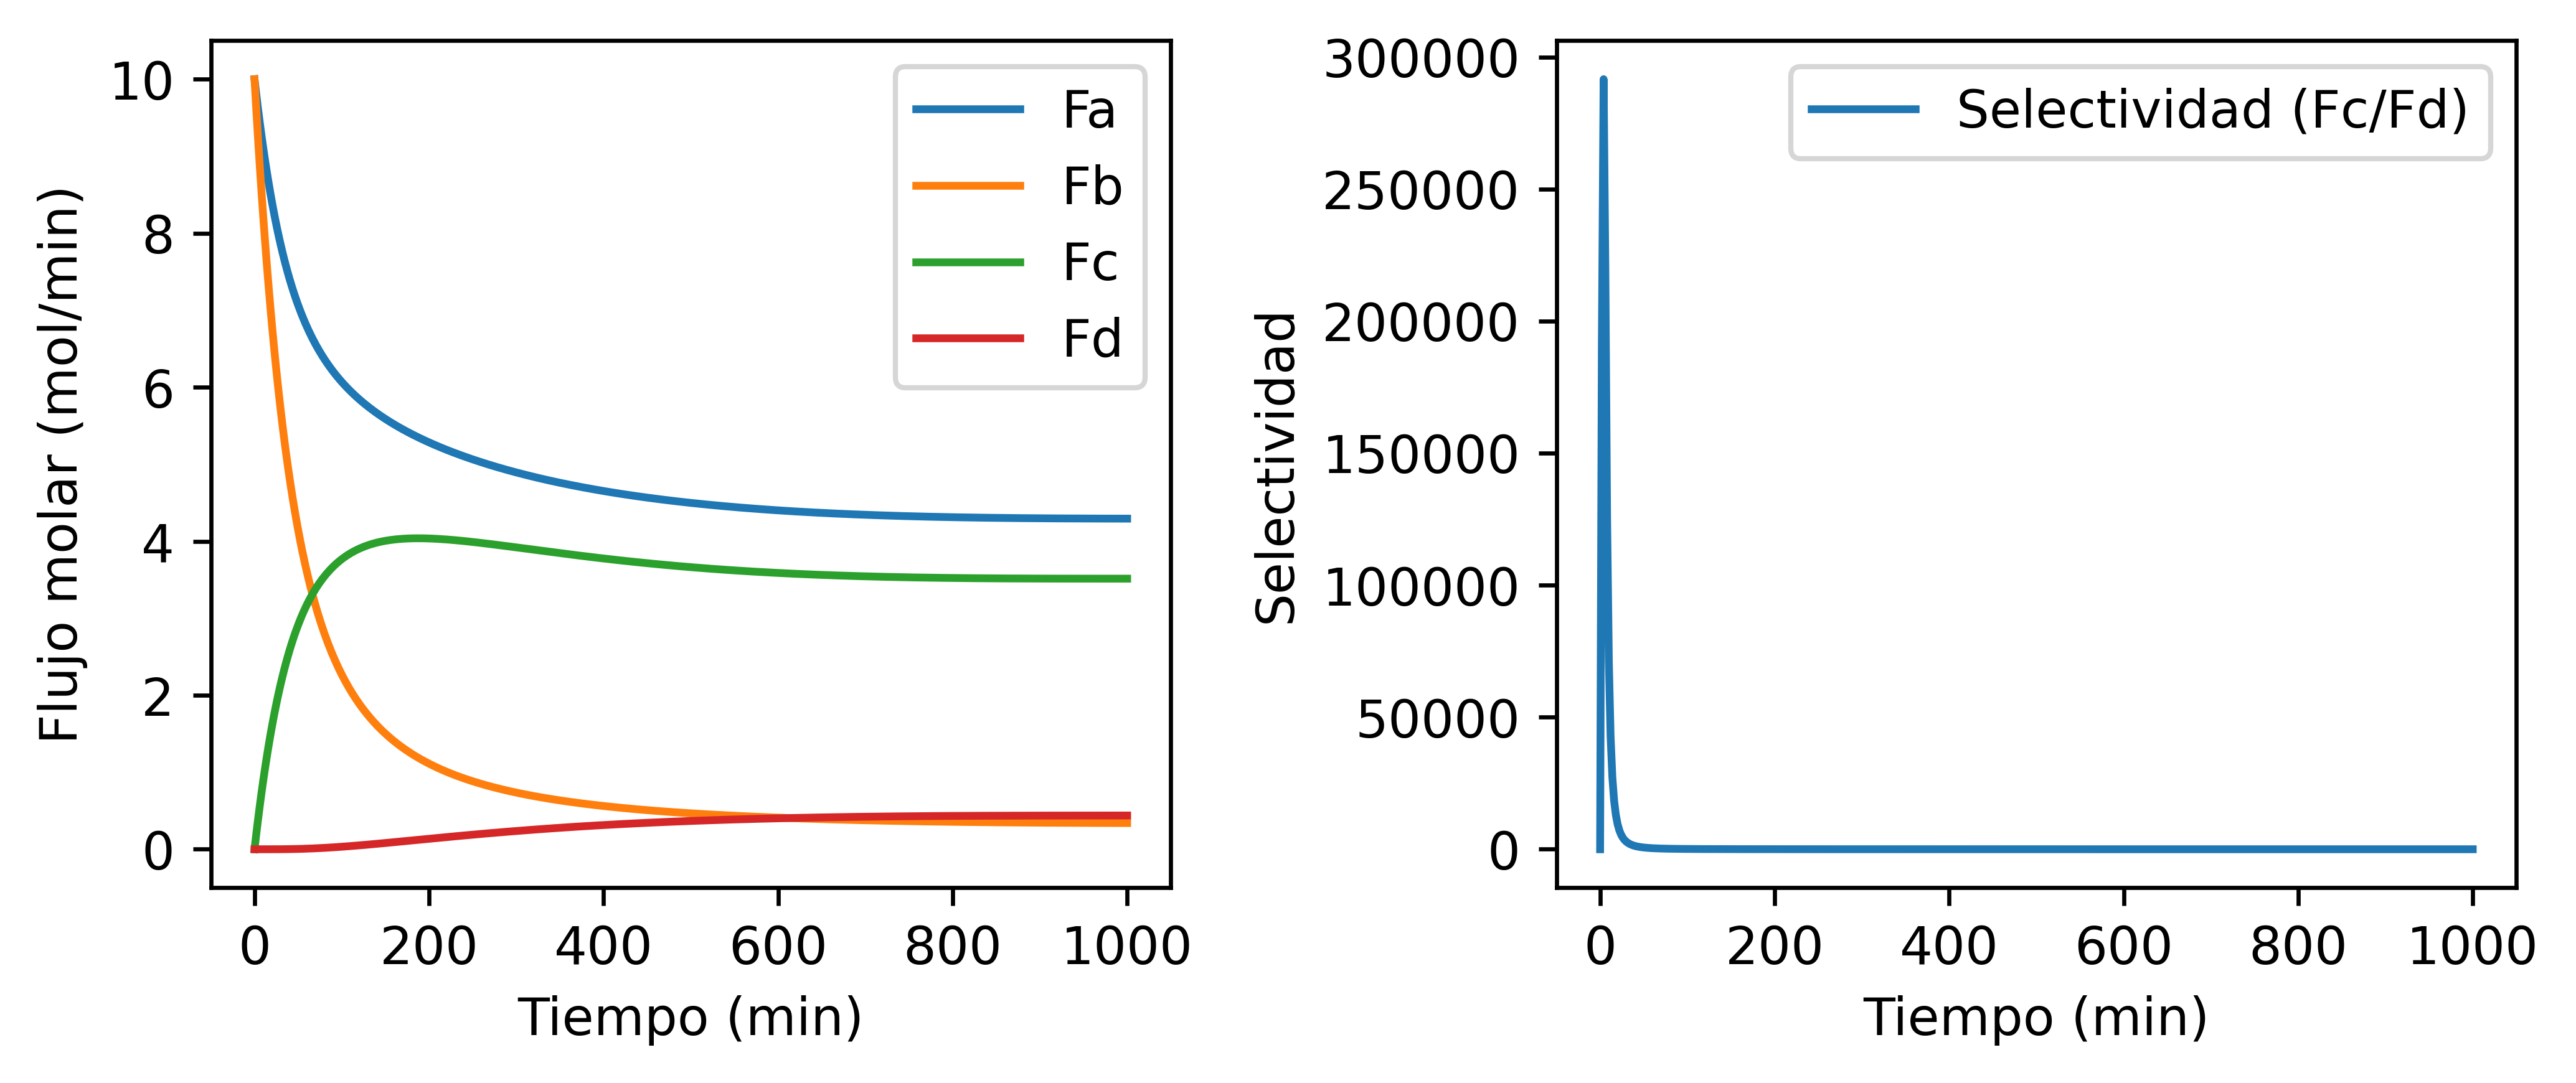

In [ ]:
def edo3(t, x, K):
    ct0, alpha, v0, k1a, k2c, Ft0 = K
    fa, fb, fc, fd, p = x
    # ft
    Ft = fa + fb + fc + fd
    # concentraciones
    ca = ct0 * (fa / Ft) * p
    cb = ct0 * (fb / Ft) * p
    cc = ct0 * (fc / Ft) * p
    cd = ct0 * (fd / Ft) * p
    # derivadas
    dfa_dw = -k1a * ca * cb**2 - 2/3 * k2c * ca**2 * cc ** 3
    dfb_dw = -2 * k1a * ca * cb**2
    dfc_dw = k1a * ca * cb**2 - k2c * ca**2 * cc ** 3
    dfd_dw = 1/3 * k2c * ca**2 * cc ** 3
    dp_dw = -  alpha / (2 * p) * (Ft / Ft0)
    return [dfa_dw, dfb_dw, dfc_dw, dfd_dw, dp_dw]

# Parámetros
ct0 = 0.2 #mol/dm3
alpha = 0.0019 # kg-1
v0 = 100 # dm3 / min
k1a = 100 # ( dm3/mol)^2 / min / kg-cat
k2c = 1500 # ( dm15/mol^4) / min / kg-cat
Ft0 = 20 # mol/min
k = [ct0, alpha, v0, k1a, k2c, Ft0]
# Condiciones iniciales
fa0 = 10
fb0 = 10
fc0 = 0
fd0 = 0
p0 = 1

t_eval = np.linspace(0, 1000, 500)
sol = scipy.integrate.solve_ivp(edo3, 
                                t_span=(t_eval[0], t_eval[-1]), 
                                y0=
                                [fa0, fb0, fc0, fd0, p0], 
                                args=(k,), 
                                t_eval=t_eval,
                                method='BDF',
                                atol=1e-10,
                                rtol=1e-10)

fa_sol, fb_sol, fc_sol, fd_sol, p_sol = sol.y
selectividad = fc_sol / (fd_sol + 1e-6)  # Evitar división por cero
fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi = 600)


ax[0].plot(sol.t, fa_sol, label='Fa')
ax[0].plot(sol.t, fb_sol, label='Fb')
ax[0].plot(sol.t, fc_sol, label='Fc')
ax[0].plot(sol.t, fd_sol, label='Fd')
ax[0].set_xlabel('Tiempo (min)')
ax[0].set_ylabel('Flujo molar (mol/min)')
ax[0].legend()
# second
ax[1].plot(sol.t, selectividad, label='Selectividad (Fc/Fd)')   
ax[1].set_xlabel('Tiempo (min)')
ax[1].set_ylabel('Selectividad')
ax[1].legend()
plt.tight_layout()
plt.show()
fig.savefig('ayu6_rxn_multiples2.pdf', dpi=600)